<a href="https://colab.research.google.com/github/Ab-126/Deep_Learning/blob/main/early_stopping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import tensorflow as tf
import numpy as np
import pandas as pd
from pylab import rcParams
import matplotlib.pyplot as plt
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
from keras import layers
import seaborn as sns

In [19]:
X, y = make_circles(n_samples=100, noise=0.1, random_state=1)

<Axes: >

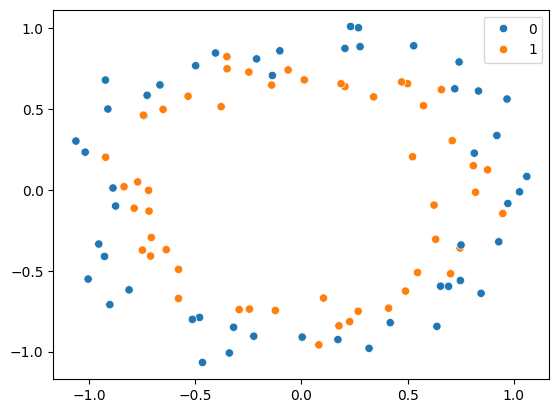

In [20]:
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [22]:
model = Sequential()

model.add(layers.Input(shape=(2, )))
model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [23]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [24]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=1000, verbose=1)

Epoch 1/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.4875 - loss: 0.6921 - val_accuracy: 0.4000 - val_loss: 0.6998
Epoch 2/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5125 - loss: 0.6899 - val_accuracy: 0.4000 - val_loss: 0.7003
Epoch 3/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5750 - loss: 0.6884 - val_accuracy: 0.4000 - val_loss: 0.7028
Epoch 4/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5625 - loss: 0.6874 - val_accuracy: 0.4000 - val_loss: 0.7046
Epoch 5/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5500 - loss: 0.6863 - val_accuracy: 0.4000 - val_loss: 0.7058
Epoch 6/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5500 - loss: 0.6852 - val_accuracy: 0.4000 - val_loss: 0.7076
Epoch 7/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5625 - loss: 0.6852 - val_accuracy: 0.4000 - val_loss: 0.7098
Epoch 8/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5625 - loss: 0.6839 - val_accuracy: 0.4000 - 

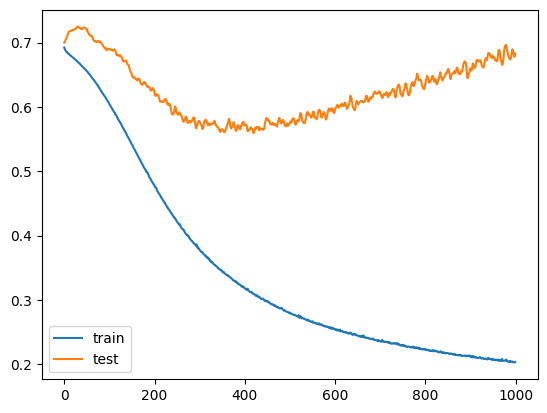

In [25]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


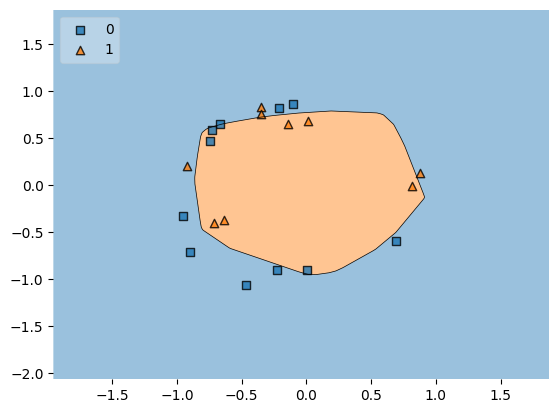

In [26]:
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend=2)
plt.show()

## Early Stopping

In [33]:
model = Sequential()

model.add(layers.Input(shape=(2, )))
model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [34]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [40]:
callback = EarlyStopping(
  monitor = "val_loss",
  min_delta = 0.00001,
  patience = 100,
  verbose = 1,
  mode = "auto",
  baseline = None,
  restore_best_weights = False
)

In [41]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3500, callbacks=callback)

Epoch 1/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5750 - loss: 0.6767 - val_accuracy: 0.3500 - val_loss: 0.7193
Epoch 2/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5750 - loss: 0.6761 - val_accuracy: 0.3500 - val_loss: 0.7198
Epoch 3/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6000 - loss: 0.6756 - val_accuracy: 0.3500 - val_loss: 0.7197
Epoch 4/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5875 - loss: 0.6750 - val_accuracy: 0.3500 - val_loss: 0.7198
Epoch 5/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5875 - loss: 0.6743 - val_accuracy: 0.3500 - val_loss: 0.7204
Epoch 6/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6000 - loss: 0.6740 - val_accuracy: 0.3500 - val_loss: 0.7204
Epoch 7/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6000 - loss: 0.6734 - val_accuracy: 0.3000 - val_loss: 0.7206
Epoch 8/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6125 - loss: 0.6728 - val_accuracy: 0.2500 - v

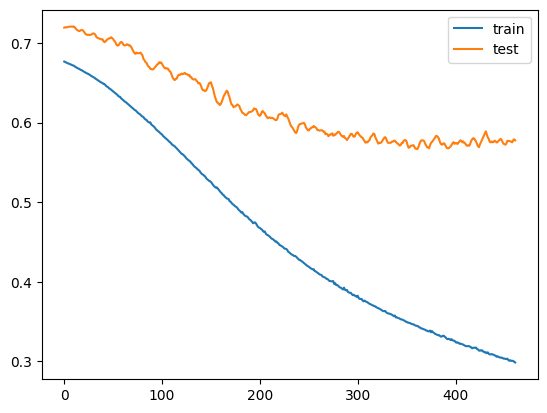

In [42]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


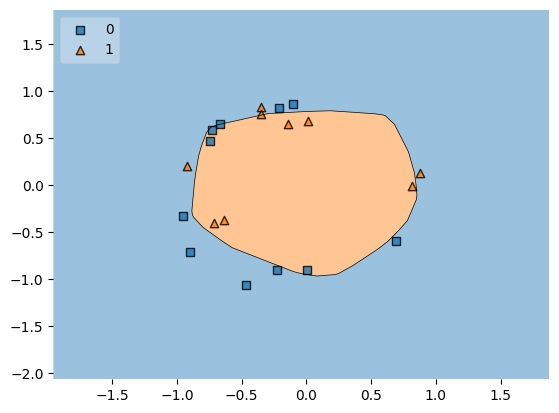

In [43]:
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend=2)
plt.show()